In [3]:
import os
os.getcwd()

'C:\\Users\\Sipun\\Desktop\\ML-Career-Intelligence'

In [4]:
import os

os.path.exists("../data/raw/jobs.csv")

False

In [5]:
import pandas as pd

df = pd.read_csv("data/raw/jobs.csv")

df.head()

,job_id,title,experience,education,python,java,sql,ml,deep_learning,cloud,salary
0,1,Data Scientist,2,Bachelor,1,0,1,1,0,1,65000
1,2,ML Engineer,3,Master,1,0,1,1,1,1,85000
2,3,Backend Developer,2,Bachelor,1,1,1,0,0,1,60000
3,4,Data Analyst,1,Bachelor,1,0,1,0,0,0,45000
4,5,AI Engineer,4,Master,1,0,1,1,1,1,95000


In [6]:
df.shape

(20, 11)

In [7]:
df.columns

Index(['job_id', 'title', 'experience', 'education', 'python', 'java', 'sql',
       'ml', 'deep_learning', 'cloud', 'salary'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   job_id         20 non-null     int64
 1   title          20 non-null     str  
 2   experience     20 non-null     int64
 3   education      20 non-null     str  
 4   python         20 non-null     int64
 5   java           20 non-null     int64
 6   sql            20 non-null     int64
 7   ml             20 non-null     int64
 8   deep_learning  20 non-null     int64
 9   cloud          20 non-null     int64
 10  salary         20 non-null     int64
dtypes: int64(9), str(2)
memory usage: 2.3 KB


In [9]:
df.isnull().sum()

job_id           0
title            0
experience       0
education        0
python           0
java             0
sql              0
ml               0
deep_learning    0
cloud            0
salary           0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,job_id,experience,python,java,sql,ml,deep_learning,cloud,salary
count,20.00000,20.000000,20.000000,20.000000,20.0,20.000000,20.000000,20.000000,20.000000
mean,10.50000,2.900000,0.900000,0.300000,1.0,0.550000,0.450000,0.800000,75300.000000
std,5.91608,1.293709,0.307794,0.470162,0.0,0.510418,0.510418,0.410391,19934.365989
min,1.00000,1.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,43000.000000
25%,5.75000,2.000000,1.000000,0.000000,1.0,0.000000,0.000000,1.000000,63750.000000
50%,10.50000,3.000000,1.000000,0.000000,1.0,1.000000,0.000000,1.000000,76500.000000
75%,15.25000,4.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,89000.000000
max,20.00000,5.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,110000.000000


In [12]:
df["title"].value_counts()

title
Data Scientist       4
ML Engineer          4
Backend Developer    3
Data Analyst         3
AI Engineer          3
Software Engineer    3
Name: count, dtype: int64

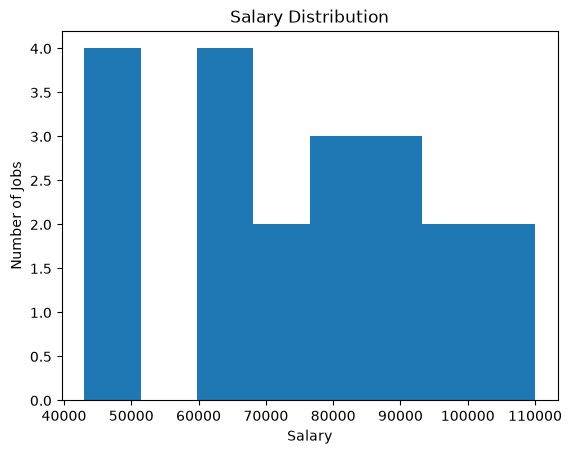

In [13]:
import matplotlib.pyplot as plt

df["salary"].plot(kind="hist", bins=8)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Number of Jobs")
plt.show()

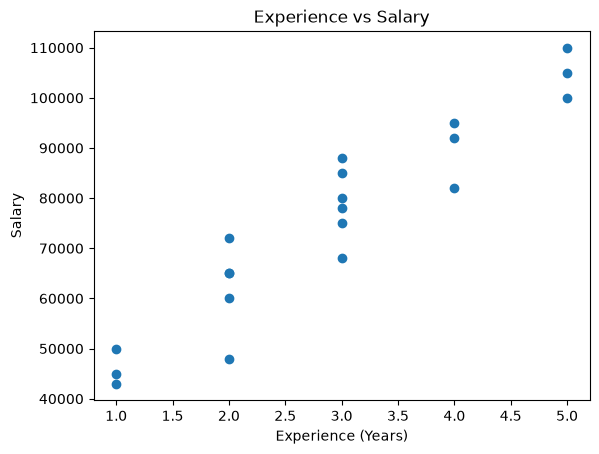

In [14]:
plt.scatter(df["experience"], df["salary"])

plt.title("Experience vs Salary")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")
plt.show()

In [15]:
df["education_encoded"] = df["education"].map({
    "Bachelor": 0,
    "Master": 1
})

df[["education", "education_encoded"]].head()

,education,education_encoded
0,Bachelor,0
1,Master,1
2,Bachelor,0
3,Bachelor,0
4,Master,1


In [16]:
skill_columns = [
    "python",
    "java",
    "sql",
    "ml",
    "deep_learning",
    "cloud"
]

df["total_skills"] = df[skill_columns].sum(axis=1)

df[["title", "total_skills"]].head()

,title,total_skills
0,Data Scientist,4
1,ML Engineer,5
2,Backend Developer,4
3,Data Analyst,2
4,AI Engineer,5


In [17]:
features = [
    "experience",
    "education_encoded",
    "python",
    "java",
    "sql",
    "ml",
    "deep_learning",
    "cloud",
    "total_skills"
]

X = df[features]
y = df["salary"]

In [18]:
X.head()

,experience,education_encoded,python,java,sql,ml,deep_learning,cloud,total_skills
0,2,0,1,0,1,1,0,1,4
1,3,1,1,0,1,1,1,1,5
2,2,0,1,1,1,0,0,1,4
3,1,0,1,0,1,0,0,0,2
4,4,1,1,0,1,1,1,1,5


In [19]:
y.head()

0    65000
1    85000
2    60000
3    45000
4    95000
Name: salary, dtype: int64

In [20]:
X.shape

(20, 9)

In [21]:
y.shape

(20,)

In [22]:
from sklearn.linear_model import LinearRegression

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
model = LinearRegression()

In [25]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[ 9170.21, 6106.38,-2029.55,..., 1913.71,-7362.88, 6192.67]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['experience','education_encoded','python',...,'deep_learning','cloud', 'total_skills']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.239e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


In [26]:
y_pred = model.predict(X_test)

y_pred

array([62723.40425532, 63163.12056738, 41914.89361702, 86106.38297872])

In [27]:
comparison = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Predicted Salary": y_pred
})

comparison

,Actual Salary,Predicted Salary
0,65000,62723.404255
1,65000,63163.120567
2,43000,41914.893617
3,85000,86106.382979


In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [29]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R²:", r2)

MAE: 1576.2411347517846
MSE: 2739638.3481716523
R²: 0.9875894072563005


In [30]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,experience,9.170213e+03
1,education_encoded,6.106383e+03
2,python,-2.029551e+03
3,java,7.055556e+03
4,sql,-3.637979e-12
5,ml,6.615839e+03
6,deep_learning,1.913712e+03
7,cloud,-7.362884e+03
8,total_skills,6.192671e+03


In [31]:
coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
0,experience,9.170213e+03
3,java,7.055556e+03
5,ml,6.615839e+03
8,total_skills,6.192671e+03
1,education_encoded,6.106383e+03
6,deep_learning,1.913712e+03
4,sql,-3.637979e-12
2,python,-2.029551e+03
7,cloud,-7.362884e+03


In [32]:
classification_features = [
    "experience",
    "education_encoded",
    "python",
    "java",
    "sql",
    "ml",
    "deep_learning",
    "cloud",
    "total_skills"
]

X_class = df[classification_features]
y_class = df["title"]

In [33]:
X_class.head()

,experience,education_encoded,python,java,sql,ml,deep_learning,cloud,total_skills
0,2,0,1,0,1,1,0,1,4
1,3,1,1,0,1,1,1,1,5
2,2,0,1,1,1,0,0,1,4
3,1,0,1,0,1,0,0,0,2
4,4,1,1,0,1,1,1,1,5


In [34]:
y_class.head()

0       Data Scientist
1          ML Engineer
2    Backend Developer
3         Data Analyst
4          AI Engineer
Name: title, dtype: str

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42
)

In [36]:
from sklearn.linear_model import LogisticRegression

In [37]:
logistic_model = LogisticRegression(max_iter=1000)

In [38]:
logistic_model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [39]:
y_pred = logistic_model.predict(X_test)

y_pred

array(['ML Engineer', 'Backend Developer', 'Data Analyst', 'AI Engineer'],
      dtype=object)

In [40]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.25


In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, zero_division=0))

                   precision    recall  f1-score   support

      AI Engineer       0.00      0.00      0.00         0
Backend Developer       0.00      0.00      0.00         0
     Data Analyst       1.00      1.00      1.00         1
   Data Scientist       0.00      0.00      0.00         1
      ML Engineer       0.00      0.00      0.00         1
Software Engineer       0.00      0.00      0.00         1

         accuracy                           0.25         4
        macro avg       0.17      0.17      0.17         4
     weighted avg       0.25      0.25      0.25         4



In [42]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, tree_pred))

Decision Tree Accuracy: 0.25


In [43]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

forest_model.fit(X_train, y_train)

forest_pred = forest_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, forest_pred))

Random Forest Accuracy: 0.25


In [44]:
from sklearn.svm import SVC

svm_model = SVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("SVM Accuracy:",
      accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.0


In [45]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, forest_pred),
        accuracy_score(y_test, svm_pred)
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
0,Logistic Regression,0.25
1,Decision Tree,0.25
2,Random Forest,0.25
3,SVM,0.00


In [46]:
cluster_features = [
    "experience",
    "python",
    "java",
    "sql",
    "ml",
    "deep_learning",
    "cloud"
]

X_cluster = df[cluster_features]

X_cluster.head()

,experience,python,java,sql,ml,deep_learning,cloud
0,2,1,0,1,1,0,1
1,3,1,0,1,1,1,1
2,2,1,1,1,0,0,1
3,1,1,0,1,0,0,0
4,4,1,0,1,1,1,1


In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

In [48]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters

df[["title", "cluster"]].head(10)

,title,cluster
0,Data Scientist,2
1,ML Engineer,2
2,Backend Developer,0
3,Data Analyst,1
4,AI Engineer,2
5,Software Engineer,0
6,Data Scientist,2
7,Backend Developer,0
8,ML Engineer,1
9,Data Analyst,1


In [49]:
df.groupby("cluster")[cluster_features].mean()

,experience,python,java,sql,ml,deep_learning,cloud
cluster,,,,,,,
0,2.5,0.666667,1.0,1.0,0.00,0.00,1.0
1,1.5,1.000000,0.0,1.0,0.25,0.25,0.0
2,3.7,1.000000,0.0,1.0,1.00,0.80,1.0


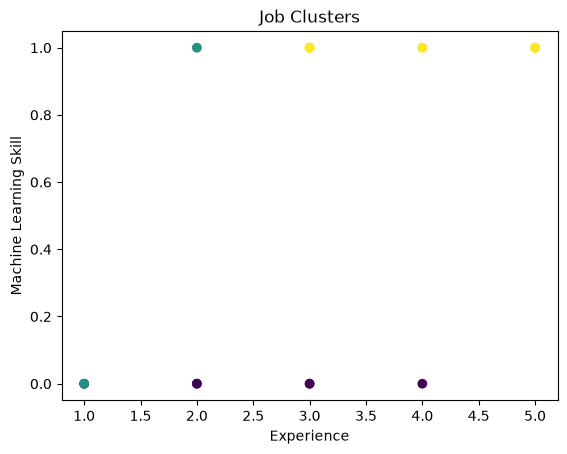

In [50]:
import matplotlib.pyplot as plt

plt.scatter(
    df["experience"],
    df["ml"],
    c=df["cluster"]
)

plt.xlabel("Experience")
plt.ylabel("Machine Learning Skill")
plt.title("Job Clusters")
plt.show()

In [51]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=3
)

hierarchical_clusters = hierarchical.fit_predict(X_scaled)

df["hierarchical_cluster"] = hierarchical_clusters

df[["title", "hierarchical_cluster"]].head(10)

,title,hierarchical_cluster
0,Data Scientist,1
1,ML Engineer,1
2,Backend Developer,0
3,Data Analyst,2
4,AI Engineer,1
5,Software Engineer,0
6,Data Scientist,1
7,Backend Developer,0
8,ML Engineer,2
9,Data Analyst,2


In [52]:
df.groupby("hierarchical_cluster")[cluster_features].mean()

,experience,python,java,sql,ml,deep_learning,cloud
hierarchical_cluster,,,,,,,
0,2.5,0.666667,1.0,1.0,0.00,0.00,1.0
1,3.7,1.000000,0.0,1.0,1.00,0.80,1.0
2,1.5,1.000000,0.0,1.0,0.25,0.25,0.0


In [53]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

X_pca.shape

(20, 2)

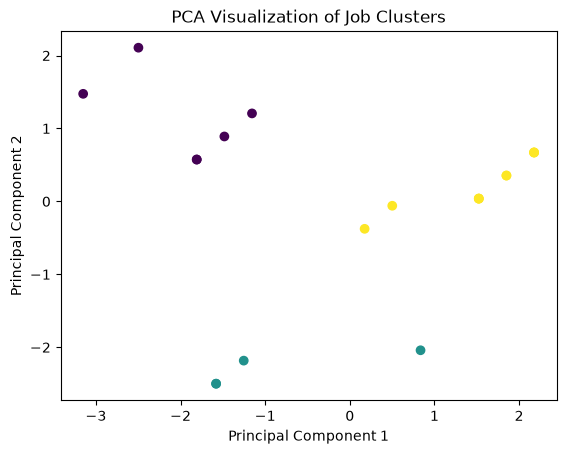

In [54]:
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["cluster"]
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Job Clusters")
plt.show()

In [55]:
from xgboost import XGBRegressor

In [56]:
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [57]:
xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)

In [58]:
xgb_model.fit(X_train_reg, y_train_reg)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [59]:
xgb_pred = xgb_model.predict(X_test_reg)

In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

xgb_mae = mean_absolute_error(y_test_reg, xgb_pred)
xgb_mse = mean_squared_error(y_test_reg, xgb_pred)
xgb_r2 = r2_score(y_test_reg, xgb_pred)

print("XGBoost MAE:", xgb_mae)
print("XGBoost MSE:", xgb_mse)
print("XGBoost R²:", xgb_r2)

XGBoost MAE: 4478.12890625
XGBoost MSE: 22620966.0
XGBoost R²: 0.897526741027832


In [61]:
from sklearn.model_selection import cross_val_score

In [62]:
cv_scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("CV Scores:", cv_scores)
print("Average R²:", cv_scores.mean())

CV Scores: [0.89648169 0.90377271 0.80947423 0.94159257 0.89935452]
Average R²: 0.8901351451873779


In [63]:
from sklearn.model_selection import GridSearchCV

In [64]:
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.05, 0.1]
}

In [65]:
grid_search = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2"
)

In [66]:
grid_search.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [2, 3, ...], 'n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls th

In [67]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}


In [68]:
print("Best CV R²:")
print(grid_search.best_score_)

Best CV R²:
0.9300296187400818


In [69]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
8,total_skills,0.746260
5,ml,0.141881
0,experience,0.058148
1,education_encoded,0.042568
2,python,0.004914
3,java,0.004496
6,deep_learning,0.001733
4,sql,0.000000
7,cloud,0.000000


In [70]:
recommendation_features = [
    "python",
    "java",
    "sql",
    "ml",
    "deep_learning",
    "cloud"
]

job_vectors = df[recommendation_features]

job_vectors.head()

,python,java,sql,ml,deep_learning,cloud
0,1,0,1,1,0,1
1,1,0,1,1,1,1
2,1,1,1,0,0,1
3,1,0,1,0,0,0
4,1,0,1,1,1,1


In [71]:
candidate = [[1, 0, 1, 1, 1, 0]]

In [72]:
from sklearn.metrics.pairwise import cosine_similarity

In [73]:
similarities = cosine_similarity(
    candidate,
    job_vectors
)[0]

In [74]:
recommendations = df[
    ["job_id", "title", "salary"]
].copy()

recommendations["match_score"] = similarities * 100

In [75]:
recommendations = recommendations.sort_values(
    by="match_score",
    ascending=False
)

recommendations.head(5)

,job_id,title,salary,match_score
8,9,ML Engineer,72000,100.000000
1,2,ML Engineer,85000,89.442719
4,5,AI Engineer,95000,89.442719
10,11,AI Engineer,88000,89.442719
16,17,AI Engineer,110000,89.442719


In [76]:
def recommend_jobs(candidate_skills, top_n=5):

    similarities = cosine_similarity(
        [candidate_skills],
        job_vectors
    )[0]

    result = df[
        ["job_id", "title", "salary"]
    ].copy()

    result["match_score"] = similarities * 100

    result = result.sort_values(
        "match_score",
        ascending=False
    )

    return result.head(top_n)

In [77]:
recommend_jobs(
    [1, 0, 1, 1, 1, 0]
)

,job_id,title,salary,match_score
8,9,ML Engineer,72000,100.000000
1,2,ML Engineer,85000,89.442719
4,5,AI Engineer,95000,89.442719
10,11,AI Engineer,88000,89.442719
16,17,AI Engineer,110000,89.442719


In [78]:
recommend_jobs(
    [1, 1, 1, 0, 0, 1]
)

,job_id,title,salary,match_score
2,3,Backend Developer,60000,100.00000
17,18,Software Engineer,65000,100.00000
11,12,Software Engineer,82000,100.00000
5,6,Software Engineer,75000,100.00000
14,15,Backend Developer,68000,86.60254


In [79]:
recommend_jobs(
    [1, 0, 1, 1, 1, 1]
)

,job_id,title,salary,match_score
1,2,ML Engineer,85000,100.0
10,11,AI Engineer,88000,100.0
6,7,Data Scientist,100000,100.0
4,5,AI Engineer,95000,100.0
16,17,AI Engineer,110000,100.0


In [80]:
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(
    n_neighbors=5,
    metric="cosine"
)

knn.fit(job_vectors)

,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
effective_metric_ effective_metric_: strMetric used to compute distances to neighbors.,str,'cosine'
effective_metric_params_ effective_metric_params_: dictParameters for the metric used to compute distances to neighbors.,dict,{}


In [81]:
distances, indices = knn.kneighbors(
    [[1, 0, 1, 1, 1, 0]]
)

C:\Users\Sipun\Desktop\ML-Career-Intelligence\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


In [82]:
knn_results = df.iloc[indices[0]][
    ["title", "salary"]
].copy()

knn_results["distance"] = distances[0]

knn_results

,title,salary,distance
8,ML Engineer,72000,0.000000
1,ML Engineer,85000,0.105573
6,Data Scientist,100000,0.105573
4,AI Engineer,95000,0.105573
10,AI Engineer,88000,0.105573


In [83]:
knn_results["match_score"] = (
    1 - knn_results["distance"]
) * 100

knn_results

,title,salary,distance,match_score
8,ML Engineer,72000,0.000000,100.000000
1,ML Engineer,85000,0.105573,89.442719
6,Data Scientist,100000,0.105573,89.442719
4,AI Engineer,95000,0.105573,89.442719
10,AI Engineer,88000,0.105573,89.442719


In [84]:
resume = """
Python developer with 3 years of experience.
Skilled in Python, SQL, machine learning, Pandas,
deep learning and data analysis.
"""

job_description = """
We are looking for an ML Engineer with experience
in Python, SQL, machine learning, deep learning,
and data analysis.
"""

In [85]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [86]:
vectorizer = TfidfVectorizer(
    stop_words="english"
)

In [87]:
tfidf_matrix = vectorizer.fit_transform([
    resume,
    job_description
])

In [88]:
tfidf_matrix.shape

(2, 15)

In [89]:
from sklearn.metrics.pairwise import cosine_similarity

tfidf_similarity = cosine_similarity(
    tfidf_matrix[0:1],
    tfidf_matrix[1:2]
)[0][0]

print("TF-IDF Match:", round(tfidf_similarity * 100, 2), "%")

TF-IDF Match: 62.33 %


In [90]:
from sentence_transformers import SentenceTransformer

In [91]:
embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [92]:
resume_embedding = embedding_model.encode(resume)

job_embedding = embedding_model.encode(job_description)

In [93]:
semantic_similarity = cosine_similarity(
    [resume_embedding],
    [job_embedding]
)[0][0]

print(
    "Semantic Match:",
    round(semantic_similarity * 100, 2),
    "%"
)

Semantic Match: 71.94 %


In [94]:
print("TF-IDF Match:",
      round(tfidf_similarity * 100, 2), "%")

print("Transformer Match:",
      round(semantic_similarity * 100, 2), "%")

TF-IDF Match: 62.33 %
Transformer Match: 71.94 %


In [95]:
def calculate_job_match(resume_text, job_text):

    resume_embedding = embedding_model.encode(
        resume_text
    )

    job_embedding = embedding_model.encode(
        job_text
    )

    similarity = cosine_similarity(
        [resume_embedding],
        [job_embedding]
    )[0][0]

    return round(similarity * 100, 2)

In [96]:
score = calculate_job_match(
    resume,
    job_description
)

print("Job Match:", score, "%")

Job Match: 71.94 %


In [97]:
import torch
import torch.nn as nn
import torch.optim as optim

In [98]:
X_dl = X.copy()
y_dl = y.copy()

In [99]:
X_dl = X_dl.values
y_dl = y_dl.values

In [100]:
from sklearn.model_selection import train_test_split

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_dl,
    y_dl,
    test_size=0.2,
    random_state=42
)

In [101]:
X_train_tensor = torch.tensor(
    X_train_dl,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_dl,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train_dl,
    dtype=torch.float32
).reshape(-1, 1)

y_test_tensor = torch.tensor(
    y_test_dl,
    dtype=torch.float32
).reshape(-1, 1)

In [102]:
class SalaryNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(9, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)

In [103]:
model_dl = SalaryNetwork()

print(model_dl)

SalaryNetwork(
  (network): Sequential(
    (0): Linear(in_features=9, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)


In [104]:
criterion = nn.MSELoss()

In [105]:
optimizer = optim.Adam(
    model_dl.parameters(),
    lr=0.001
)

In [106]:
epochs = 500

for epoch in range(epochs):

    predictions = model_dl(X_train_tensor)

    loss = criterion(
        predictions,
        y_train_tensor
    )

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(
            f"Epoch {epoch + 1}, Loss: {loss.item():.2f}"
        )

Epoch 100, Loss: 6463306240.00
Epoch 200, Loss: 6456043008.00
Epoch 300, Loss: 6432844800.00
Epoch 400, Loss: 6385141248.00
Epoch 500, Loss: 6305736704.00


In [ ]:
with torch.no_grad():

    predictions = model_dl(
        X_test_tensor
    )

predictions = predictions.numpy()

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

dl_mae = mean_absolute_error(
    y_test_dl,
    predictions
)

dl_r2 = r2_score(
    y_test_dl,
    predictions
)

print("Neural Network MAE:", dl_mae)
print("Neural Network R²:", dl_r2)

In [ ]:
with open(
    "data/raw/career_knowledge.txt",
    "r",
    encoding="utf-8"
) as file:
    text = file.read()

print(text[:1000])

In [ ]:
def create_chunks(text, chunk_size=300):

    words = text.split()

    chunks = []

    for i in range(0, len(words), chunk_size):
        chunk = " ".join(
            words[i:i + chunk_size]
        )

        chunks.append(chunk)

    return chunks

In [ ]:
chunks = create_chunks(text)

print("Number of chunks:", len(chunks))

In [ ]:
print(chunks[0])

In [ ]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

In [ ]:
chunk_embeddings = embedding_model.encode(
    chunks
)

In [ ]:
chunk_embeddings.shape

In [ ]:
import faiss
import numpy as np

In [ ]:
chunk_embeddings = np.array(
    chunk_embeddings
).astype("float32")

In [ ]:
index = faiss.IndexFlatL2(
    chunk_embeddings.shape[1]
)

In [ ]:
index.add(chunk_embeddings)

In [ ]:
question = "What skills does an ML Engineer need?"

In [ ]:
question_embedding = embedding_model.encode(
    [question]
)

question_embedding = np.array(
    question_embedding
).astype("float32")

In [ ]:
distances, indices = index.search(
    question_embedding,
    k=3
)

In [ ]:
for i in indices[0]:
    print("----")
    print(chunks[i])

In [ ]:
retrieved_context = "\n\n".join(
    chunks[i] for i in indices[0]
)

print(retrieved_context)

In [ ]:
prompt = f"""
Answer the question using only the provided context.

Context:
{retrieved_context}

Question:
{question}

If the answer is not present in the context,
say that you do not have enough information.
"""

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("OPENAI_API_KEY")

print("API key loaded:", api_key is not None)

In [ ]:
from openai import OpenAI

client = OpenAI(api_key=api_key)

In [ ]:
def rag_answer(question, k=3):

    # 1. Convert question to embedding
    question_embedding = embedding_model.encode(
        [question]
    )

    question_embedding = np.array(
        question_embedding
    ).astype("float32")

    # 2. Retrieve relevant chunks
    distances, indices = index.search(
        question_embedding,
        k
    )

    # 3. Build context
    context = "\n\n".join(
        chunks[i] for i in indices[0]
    )

    # 4. Create prompt
    prompt = f"""
You are a career assistant.

Answer the question using only the context below.

Context:
{context}

Question:
{question}

If the answer is not present in the context,
say that you do not have enough information.
"""

    # 5. Ask the LLM
    response = client.responses.create(
        model="gpt-4.1-mini",
        input=prompt
    )

    return response.output_text

In [ ]:
print(embedding_model)

In [ ]:
question = "What skills does an ML Engineer need?"

question_embedding = embedding_model.encode([question])

question_embedding = np.array(
    question_embedding
).astype("float32")

distances, indices = index.search(
    question_embedding,
    k=3
)

print("Relevant career information:\n")

for i in indices[0]:
    print("--------------------------------")
    print(chunks[i])

In [ ]:
def rag_answer(question, k=3):

    # 1. Create question embedding
    question_embedding = embedding_model.encode([question])

    question_embedding = np.array(
        question_embedding
    ).astype("float32")

    # 2. Search FAISS
    distances, indices = index.search(
        question_embedding,
        k
    )

    # 3. Retrieve context
    context = "\n\n".join(
        chunks[i] for i in indices[0]
    )

    # 4. Return retrieved information
    return context

In [ ]:
answer = rag_answer(
    "What skills does an ML Engineer need?"
)

print(answer)

In [ ]:
candidate_profile = {
    "name": "Sipun",
    "experience": 2,
    "education": "Bachelor",
    "skills": [
        "python",
        "sql",
        "machine learning"
    ]
}

candidate_profile

In [ ]:
career_skills = {
    "ML Engineer": [
        "python",
        "sql",
        "machine learning",
        "deep learning",
        "cloud",
        "docker",
        "mlops"
    ],

    "Data Scientist": [
        "python",
        "sql",
        "machine learning",
        "statistics",
        "pandas",
        "visualization"
    ],

    "Data Analyst": [
        "sql",
        "excel",
        "python",
        "statistics",
        "visualization"
    ]
}

In [ ]:
def analyze_skill_gap(candidate_skills, target_role):

    required_skills = set(
        career_skills[target_role]
    )

    candidate_skills = set(
        candidate_skills
    )

    matched = required_skills.intersection(
        candidate_skills
    )

    missing = required_skills.difference(
        candidate_skills
    )

    return {
        "matched_skills": list(matched),
        "missing_skills": list(missing),
        "match_percentage": round(
            len(matched) / len(required_skills) * 100,
            2
        )
    }

In [ ]:
result = analyze_skill_gap(
    candidate_profile["skills"],
    "ML Engineer"
)

result

In [ ]:
learning_resources = {
    "deep learning": "Study neural networks, CNNs and RNNs",
    "cloud": "Learn AWS/Azure/GCP fundamentals",
    "docker": "Learn Docker containers and images",
    "mlops": "Learn MLflow, model deployment and monitoring",
    "statistics": "Study probability, distributions and hypothesis testing",
    "pandas": "Practice data manipulation with Pandas",
    "visualization": "Learn Matplotlib and data visualization"
}

In [ ]:
def create_learning_plan(missing_skills):

    plan = []

    for skill in missing_skills:

        if skill in learning_resources:
            plan.append({
                "skill": skill,
                "action": learning_resources[skill]
            })

    return plan

In [ ]:
learning_plan = create_learning_plan(
    result["missing_skills"]
)

learning_plan

In [ ]:
def career_agent(candidate_profile, target_role):

    print("===== CAREER AGENT =====")

    print("\nCandidate:")
    print(candidate_profile["name"])

    print("\nTarget Role:")
    print(target_role)

    # Skill gap
    skill_gap = analyze_skill_gap(
        candidate_profile["skills"],
        target_role
    )

    print("\nSkill Match:")
    print(
        skill_gap["match_percentage"],
        "%"
    )

    print("\nMatched Skills:")
    print(
        skill_gap["matched_skills"]
    )

    print("\nMissing Skills:")
    print(
        skill_gap["missing_skills"]
    )

    # Learning plan
    print("\nLearning Plan:")

    plan = create_learning_plan(
        skill_gap["missing_skills"]
    )

    for item in plan:
        print(
            "-",
            item["skill"],
            ":",
            item["action"]
        )

    return skill_gap

In [ ]:
career_agent(
    candidate_profile,
    "ML Engineer"
)

In [ ]:
def search_career_knowledge(question, k=3):

    question_embedding = embedding_model.encode(
        [question]
    )

    question_embedding = np.array(
        question_embedding
    ).astype("float32")

    distances, indices = index.search(
        question_embedding,
        k
    )

    context = "\n\n".join(
        chunks[i] for i in indices[0]
    )

    return context

In [1]:
import mlflow

mlflow.set_experiment("Career Salary Prediction")

<Experiment: artifact_location='file:C:/Users/Sipun/Desktop/ML-Career-Intelligence/mlruns/1', creation_time=1788803051224, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1788803051224, lifecycle_stage='active', name='Career Salary Prediction', tags={}, trace_location=None, workspace='default'>

In [3]:
from sklearn.linear_model import LinearRegression

In [3]:
import pandas as pd

df = pd.read_csv("data/raw/jobs.csv")

df.head()

,job_id,title,experience,education,python,java,sql,ml,deep_learning,cloud,salary
0,1,Data Scientist,2,Bachelor,1,0,1,1,0,1,65000
1,2,ML Engineer,3,Master,1,0,1,1,1,1,85000
2,3,Backend Developer,2,Bachelor,1,1,1,0,0,1,60000
3,4,Data Analyst,1,Bachelor,1,0,1,0,0,0,45000
4,5,AI Engineer,4,Master,1,0,1,1,1,1,95000


In [4]:
skill_columns = [
    "python",
    "java",
    "sql",
    "ml",
    "deep_learning",
    "cloud"
]

df["education_encoded"] = df["education"].map({
    "Bachelor": 0,
    "Master": 1
})

df["total_skills"] = df[skill_columns].sum(axis=1)

In [5]:
features = [
    "experience",
    "education_encoded",
    "python",
    "java",
    "sql",
    "ml",
    "deep_learning",
    "cloud",
    "total_skills"
]

X = df[features]
y = df["salary"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20, 9)
y shape: (20,)


In [6]:
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train_reg.shape)
print("Testing:", X_test_reg.shape)

Training: (16, 9)
Testing: (4, 9)


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import mlflow

In [11]:
mlflow.set_experiment("Career Salary Prediction")

<Experiment: artifact_location='file:C:/Users/Sipun/Desktop/ML-Career-Intelligence/mlruns/1', creation_time=1788803051224, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1788803051224, lifecycle_stage='active', name='Career Salary Prediction', tags={}, trace_location=None, workspace='default'>

In [12]:
with mlflow.start_run():

    model = LinearRegression()

    model.fit(X_train_reg, y_train_reg)

    predictions = model.predict(X_test_reg)

    mae = mean_absolute_error(
        y_test_reg,
        predictions
    )

    r2 = r2_score(
        y_test_reg,
        predictions
    )

    mlflow.log_param(
        "model",
        "Linear Regression"
    )

    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("R2", r2)

    print("MAE:", mae)
    print("R²:", r2)

MAE: 1576.2411347517846
R²: 0.9875894072563005


In [7]:
import pandas as pd
import mlflow

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Load dataset
df = pd.read_csv("data/raw/jobs.csv")

# Feature engineering
skill_columns = [
    "python",
    "java",
    "sql",
    "ml",
    "deep_learning",
    "cloud"
]

df["education_encoded"] = df["education"].map({
    "Bachelor": 0,
    "Master": 1
})

df["total_skills"] = df[skill_columns].sum(axis=1)

# Features and target
features = [
    "experience",
    "education_encoded",
    "python",
    "java",
    "sql",
    "ml",
    "deep_learning",
    "cloud",
    "total_skills"
]

X = df[features]
y = df["salary"]

# Train-test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# MLflow experiment
mlflow.set_experiment("Career Salary Prediction")

# Train and track model
with mlflow.start_run():

    model = LinearRegression()

    model.fit(X_train_reg, y_train_reg)

    predictions = model.predict(X_test_reg)

    mae = mean_absolute_error(y_test_reg, predictions)
    r2 = r2_score(y_test_reg, predictions)

    # Log information to MLflow
    mlflow.log_param("model", "Linear Regression")
    mlflow.log_param("test_size", 0.2)

    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("R2", r2)

    print("Model trained successfully!")
    print("MAE:", mae)
    print("R²:", r2)

Model trained successfully!
MAE: 1576.2411347517846
R²: 0.9875894072563005


In [8]:
import joblib

joblib.dump(model, "models/salary_model.pkl")

print("Salary model saved successfully!")

Salary model saved successfully!


In [9]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv("data/raw/jobs.csv")

# Feature engineering
skill_columns = [
    "python",
    "java",
    "sql",
    "ml",
    "deep_learning",
    "cloud"
]

df["education_encoded"] = df["education"].map({
    "Bachelor": 0,
    "Master": 1
})

df["total_skills"] = df[skill_columns].sum(axis=1)

# Features
features = [
    "experience",
    "education_encoded",
    "python",
    "java",
    "sql",
    "ml",
    "deep_learning",
    "cloud",
    "total_skills"
]

X = df[features]
y = df["salary"]

# Train-test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train_reg, y_train_reg)

# Save model
joblib.dump(model, "models/salary_model.pkl")

print("Model trained and saved successfully!")

Model trained and saved successfully!


In [10]:
import joblib

test_model = joblib.load("models/salary_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [11]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Load dataset
df = pd.read_csv("data/raw/jobs.csv")

# Feature engineering
skill_columns = [
    "python",
    "java",
    "sql",
    "ml",
    "deep_learning",
    "cloud"
]

df["education_encoded"] = df["education"].map({
    "Bachelor": 0,
    "Master": 1
})

df["total_skills"] = df[skill_columns].sum(axis=1)

# Features
classification_features = [
    "experience",
    "education_encoded",
    "python",
    "java",
    "sql",
    "ml",
    "deep_learning",
    "cloud",
    "total_skills"
]

X_class = df[classification_features]
y_class = df["title"]

# Split data
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42
)

# Train model
classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

classifier.fit(X_train_class, y_train_class)

# Save model
joblib.dump(classifier, "models/job_role_model.pkl")

print("Job role model trained and saved successfully!")

Job role model trained and saved successfully!


In [12]:
test_classifier = joblib.load("models/job_role_model.pkl")

print("Classification model loaded successfully!")

Classification model loaded successfully!
